# Q Learning RTOS Visualizations: "Exclusive Fairness" Reward
### Braden Everson

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [2]:
#logs = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max.csv")
#logs = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_2.csv")
#logs = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_3.csv")
logs = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_4.csv")
#logs = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_5.csv")
baseline = pd.read_csv("../data/rtos/1_cpu_1_mixed_baseline.csv")

In [3]:
logs.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,B,9271680,3890354,35490572,9874436,0.200474,5
996,C,9276680,14282786,0,4274378,0.230336,5
997,B,9281680,3900354,35590828,9884444,0.200189,5
998,C,9286680,14292786,0,4284386,0.230626,7
999,B,9291724,3910354,35691084,9894540,0.199906,5


In [4]:
baseline.tail()

,task_id,timestamp,total_run_timf,total_io_wait_time,total_ready_wait_time,wait_pct,delta
995,B,9824418,5340572,32984184,6645814,0.147781,10
996,C,9834418,13259996,0,6412704,0.325970,10
997,B,9844418,5360572,33084440,6665822,0.147765,10
998,C,9852362,13279996,0,6428596,0.326182,10
999,C,9862362,13299996,0,6428602,0.325852,10


## Exclusive Fairness Reward Function:

### $$R = $$
We will test this model versus a baseline of always allocating 10ms time quantums in a variety of different process configurations

### Scenario 1: 1 Exclusively CPU Intensive Processes, 1 Mixed IO Leaning Process

Text(0.5, 0, 'Timestamp')

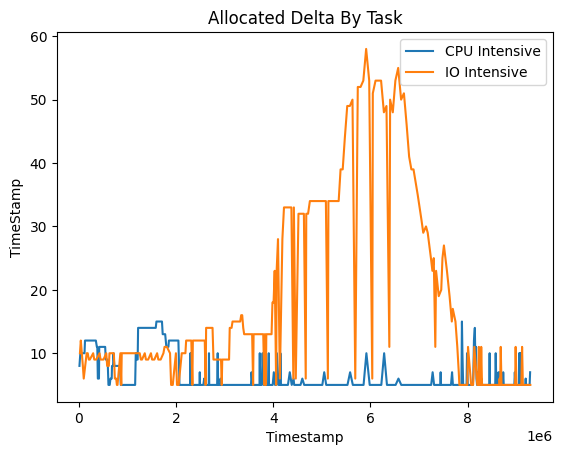

In [5]:
F = logs[logs["task_id"] == 'C']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp"], F["delta"], label="CPU Intensive")
plt.plot(B["timestamp"], B["delta"], label="IO Intensive")

plt.title("Allocated Delta By Task")

plt.legend()

plt.ylabel("TimeStamp")
plt.xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

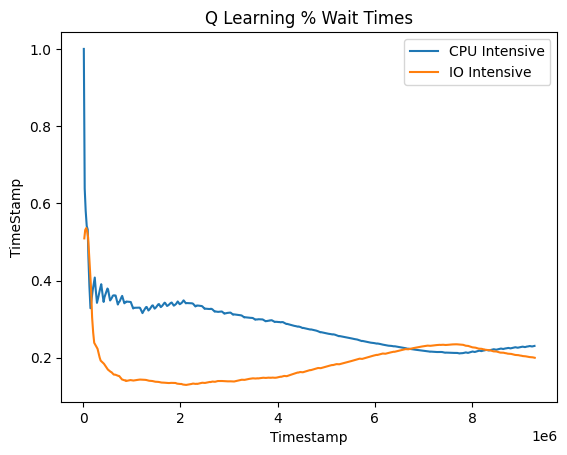

In [6]:
F = logs[logs["task_id"] == 'C']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"], label="CPU Intensive")
plt.plot(B["timestamp"], B["wait_pct"], label="IO Intensive")

plt.title("Q Learning % Wait Times")

plt.legend()

plt.ylabel("TimeStamp")
plt.xlabel("Timestamp")

Text(0, 0.5, '% Time Spent Waiting')

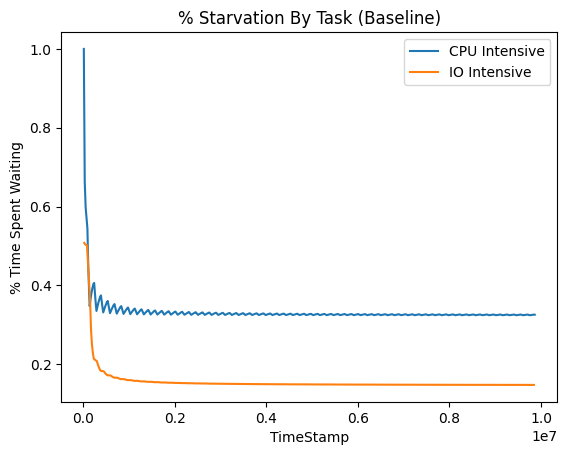

In [7]:
F = baseline[baseline["task_id"] == 'C']
B = baseline[baseline["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"], label="CPU Intensive")
plt.plot(B["timestamp"], B["wait_pct"], label="IO Intensive")

plt.title("% Starvation By Task (Baseline)")

plt.legend()

plt.xlabel("TimeStamp")
plt.ylabel("% Time Spent Waiting")

Text(0.5, 0, 'Timestamp')

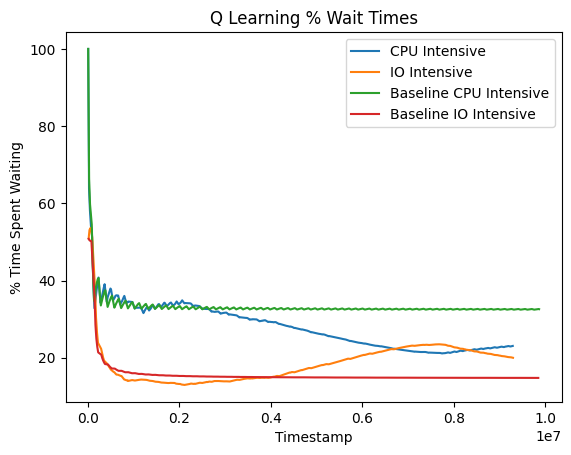

In [8]:
F = logs[logs["task_id"] == 'C']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"] * 100, label="CPU Intensive")
plt.plot(B["timestamp"], B["wait_pct"] * 100, label="IO Intensive")

F = baseline[baseline["task_id"] == 'C']
B = baseline[baseline["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"] * 100, label="Baseline CPU Intensive")
plt.plot(B["timestamp"], B["wait_pct"] * 100, label="Baseline IO Intensive")

plt.title("Q Learning % Wait Times")

plt.legend()

plt.ylabel("% Time Spent Waiting")
plt.xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

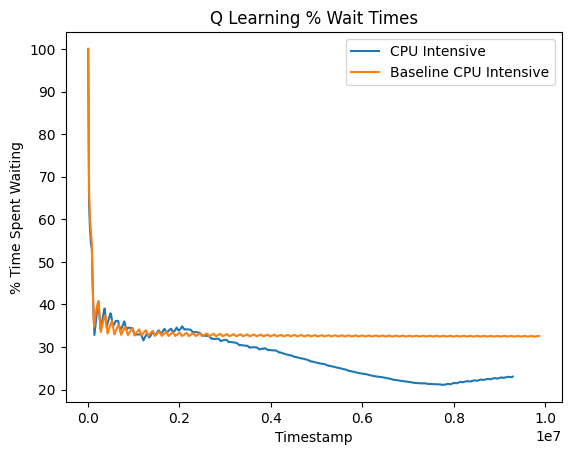

In [9]:
F = logs[logs["task_id"] == 'C']
B = logs[logs["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"] * 100, label="CPU Intensive")

F = baseline[baseline["task_id"] == 'C']
B = baseline[baseline["task_id"] == 'B']

plt.plot(F["timestamp"], F["wait_pct"] * 100, label="Baseline CPU Intensive")

plt.title("Q Learning % Wait Times")

plt.legend()

plt.ylabel("% Time Spent Waiting")
plt.xlabel("Timestamp")

Text(0.5, 0, 'Timestamp')

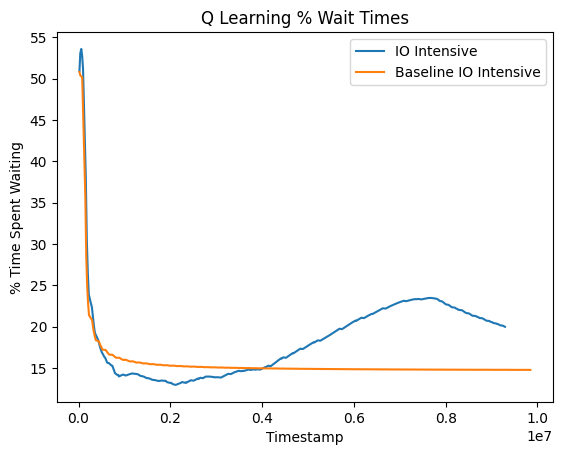

In [10]:
F = logs[logs["task_id"] == 'C']
B = logs[logs["task_id"] == 'B']

plt.plot(B["timestamp"], B["wait_pct"] * 100, label="IO Intensive")

F = baseline[baseline["task_id"] == 'C']
B = baseline[baseline["task_id"] == 'B']

plt.plot(B["timestamp"], B["wait_pct"] * 100, label="Baseline IO Intensive")

plt.title("Q Learning % Wait Times")

plt.legend()

plt.ylabel("% Time Spent Waiting")
plt.xlabel("Timestamp")

In [11]:
logs["wait_pct"].mean()

np.float64(0.24760955798999998)

In [12]:
baseline["wait_pct"].mean()

np.float64(0.27399423953)

## Kruskal Wallis

In [13]:
run0 = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max.csv")
run1 = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_2.csv")
run2 = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_3.csv")
run3 = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_4.csv")
run4 = pd.read_csv("../data/rtos/1_cpu_1_mixed_1min_200max_5.csv")

baseline0 = pd.read_csv("../data/rtos/1_cpu_1_mixed_baseline.csv")
baseline1 = pd.read_csv("../data/rtos/baseline_1.csv")
baseline2 = pd.read_csv("../data/rtos/baseline_2.csv")
baseline3 = pd.read_csv("../data/rtos/baseline_3.csv")
baseline4 = pd.read_csv("../data/rtos/baseline_4.csv")

In [14]:
avgs = [
        run0["wait_pct"].mean()*100,
        run1["wait_pct"].mean()*100,
        run2["wait_pct"].mean()*100,
        run3["wait_pct"].mean()*100,
        run4["wait_pct"].mean()*100
       ]

baseline = [
    baseline0["wait_pct"].mean()*100,
    baseline1["wait_pct"].mean()*100,
    baseline2["wait_pct"].mean()*100,
    baseline3["wait_pct"].mean()*100,
    baseline4["wait_pct"].mean()*100,
]

In [15]:
baseline

[np.float64(27.399423953000003),
 np.float64(27.399424694),
 np.float64(27.399208339000005),
 np.float64(27.399580053),
 np.float64(27.399105724)]

Text(0, 0.5, 'Average System Wait Time (%)')

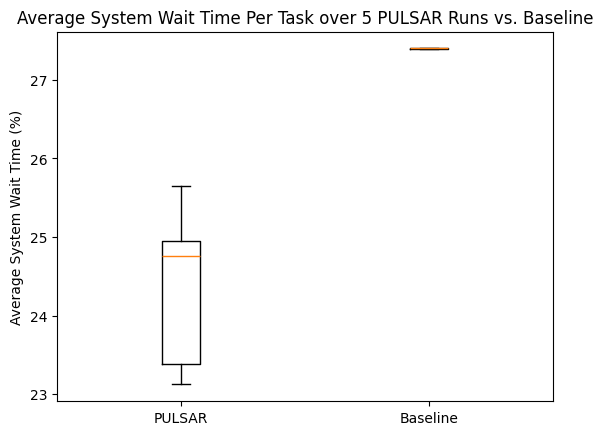

In [16]:
plt.boxplot([avgs, baseline], tick_labels=["PULSAR", "Baseline"])
plt.title("Average System Wait Time Per Task over 5 PULSAR Runs vs. Baseline")
plt.ylabel("Average System Wait Time (%)")

In [17]:
h_stat, p_val = stats.kruskal(avgs, baseline)

print(f"H-statistic: {h_stat:.4f}")
print(f"P-value: {p_val:.4f}")

H-statistic: 6.8182
P-value: 0.0090
